# Homework 4: Decision Trees and Naive Bayes
**DS4400 - Machine Learning 1**  
**Vignan Kamarthi**  
**Due: 3/27/2026 at 11pm**

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, roc_curve, auc,
    precision_score, recall_score, confusion_matrix
)
from sklearn.model_selection import train_test_split

np.random.seed(42)

## Data Loading: SPAMBASE

SPAMBASE dataset from UCI repository.  
- 57 features: 48 word frequencies, 6 character frequencies, 3 capital run-length statistics  
- Target: 1 = SPAM, 0 = HAM  
- 75/25 train/test split (same as HW3)

In [2]:
# Feature names from spambase.names
feature_names = [
    'word_freq_make', 'word_freq_address', 'word_freq_all', 'word_freq_3d',
    'word_freq_our', 'word_freq_over', 'word_freq_remove', 'word_freq_internet',
    'word_freq_order', 'word_freq_mail', 'word_freq_receive', 'word_freq_will',
    'word_freq_people', 'word_freq_report', 'word_freq_addresses', 'word_freq_free',
    'word_freq_business', 'word_freq_email', 'word_freq_you', 'word_freq_credit',
    'word_freq_your', 'word_freq_font', 'word_freq_000', 'word_freq_money',
    'word_freq_hp', 'word_freq_hpl', 'word_freq_george', 'word_freq_650',
    'word_freq_lab', 'word_freq_labs', 'word_freq_telnet', 'word_freq_857',
    'word_freq_data', 'word_freq_415', 'word_freq_85', 'word_freq_technology',
    'word_freq_1999', 'word_freq_parts', 'word_freq_pm', 'word_freq_direct',
    'word_freq_cs', 'word_freq_meeting', 'word_freq_original', 'word_freq_project',
    'word_freq_re', 'word_freq_edu', 'word_freq_table', 'word_freq_conference',
    'char_freq_;', 'char_freq_(', 'char_freq_[', 'char_freq_!',
    'char_freq_$', 'char_freq_#',
    'capital_run_length_average', 'capital_run_length_longest', 'capital_run_length_total'
]

col_names = feature_names + ['is_spam']
df_spam = pd.read_csv('spambase.data', header=None, names=col_names)

X_spam = df_spam[feature_names].values
y_spam = df_spam['is_spam'].values

X_train, X_test, y_train, y_test = train_test_split(
    X_spam, y_spam, test_size=0.25, random_state=42
)

print(f'Dataset shape: {df_spam.shape}')
print(f'Class distribution: HAM={np.sum(y_spam==0)}, SPAM={np.sum(y_spam==1)}')
print(f'Training set: {X_train.shape[0]} samples')
print(f'Testing set:  {X_test.shape[0]} samples')

Dataset shape: (4601, 58)
Class distribution: HAM=2788, SPAM=1813
Training set: 3450 samples
Testing set:  1151 samples


---
## Problem 1: Decision Trees

### Part 1: Information Gain (Entropy) -- No Pruning

In [5]:
# Problem 1.1: Decision tree with information gain (entropy), no pruning
decision_tree_entropy = DecisionTreeClassifier(criterion='entropy', random_state=42)
decision_tree_entropy.fit(X_train, y_train)

# Training predictions
y_train_pred_entropy = decision_tree_entropy.predict(X_train)
y_train_proba_entropy = decision_tree_entropy.predict_proba(X_train)[:, 1]

# Testing predictions
y_test_pred_entropy = decision_tree_entropy.predict(X_test)
y_test_proba_entropy = decision_tree_entropy.predict_proba(X_test)[:, 1]

# Training metrics
train_accuracy_entropy = accuracy_score(y_train, y_train_pred_entropy)
train_error_entropy = 1 - train_accuracy_entropy
train_f1_entropy = f1_score(y_train, y_train_pred_entropy)
train_auc_entropy = roc_auc_score(y_train, y_train_proba_entropy)

# Testing metrics
test_accuracy_entropy = accuracy_score(y_test, y_test_pred_entropy)
test_error_entropy = 1 - test_accuracy_entropy
test_f1_entropy = f1_score(y_test, y_test_pred_entropy)
test_auc_entropy = roc_auc_score(y_test, y_test_proba_entropy)

print('--- Decision Tree: Information Gain (Entropy), No Pruning ---')
print(f'Train: Accuracy={train_accuracy_entropy:.4f}, Error={train_error_entropy:.4f}, '
      f'F1={train_f1_entropy:.4f}, AUC={train_auc_entropy:.4f}')
print(f'Test:  Accuracy={test_accuracy_entropy:.4f}, Error={test_error_entropy:.4f}, '
      f'F1={test_f1_entropy:.4f}, AUC={test_auc_entropy:.4f}')
print(f'\nTree depth: {decision_tree_entropy.get_depth()}')
print(f'Number of leaves: {decision_tree_entropy.get_n_leaves()}')

--- Decision Tree: Information Gain (Entropy), No Pruning ---
Train: Accuracy=0.9994, Error=0.0006, F1=0.9993, AUC=1.0000
Test:  Accuracy=0.9235, Error=0.0765, F1=0.9060, AUC=0.9189

Tree depth: 26
Number of leaves: 185


### Part 2: Gini Index -- No Pruning

In [6]:
# Problem 1.2: Decision tree with Gini index, no pruning
decision_tree_gini = DecisionTreeClassifier(criterion='gini', random_state=42)
decision_tree_gini.fit(X_train, y_train)

# Training predictions
y_train_pred_gini = decision_tree_gini.predict(X_train)
y_train_proba_gini = decision_tree_gini.predict_proba(X_train)[:, 1]

# Testing predictions
y_test_pred_gini = decision_tree_gini.predict(X_test)
y_test_proba_gini = decision_tree_gini.predict_proba(X_test)[:, 1]

# Training metrics
train_accuracy_gini = accuracy_score(y_train, y_train_pred_gini)
train_error_gini = 1 - train_accuracy_gini
train_f1_gini = f1_score(y_train, y_train_pred_gini)
train_auc_gini = roc_auc_score(y_train, y_train_proba_gini)

# Testing metrics
test_accuracy_gini = accuracy_score(y_test, y_test_pred_gini)
test_error_gini = 1 - test_accuracy_gini
test_f1_gini = f1_score(y_test, y_test_pred_gini)
test_auc_gini = roc_auc_score(y_test, y_test_proba_gini)

print('--- Decision Tree: Gini Index, No Pruning ---')
print(f'Train: Accuracy={train_accuracy_gini:.4f}, Error={train_error_gini:.4f}, '
      f'F1={train_f1_gini:.4f}, AUC={train_auc_gini:.4f}')
print(f'Test:  Accuracy={test_accuracy_gini:.4f}, Error={test_error_gini:.4f}, '
      f'F1={test_f1_gini:.4f}, AUC={test_auc_gini:.4f}')
print(f'\nTree depth: {decision_tree_gini.get_depth()}')
print(f'Number of leaves: {decision_tree_gini.get_n_leaves()}')

--- Decision Tree: Gini Index, No Pruning ---
Train: Accuracy=0.9994, Error=0.0006, F1=0.9993, AUC=1.0000
Test:  Accuracy=0.9149, Error=0.0851, F1=0.8977, AUC=0.9154

Tree depth: 29
Number of leaves: 233


### Part 3: Pruning -- Error vs. Tree Depth

Optimal depth: 17 (test error = 0.0730)


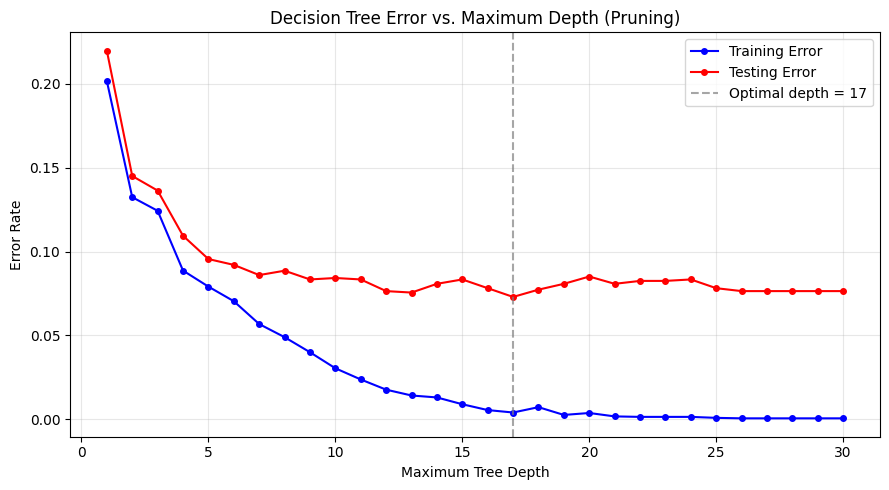

In [7]:
# Problem 1.3: Pruning via max_depth
max_depth_values = range(1, 31)
train_errors_by_depth = []
test_errors_by_depth = []

for depth in max_depth_values:
    decision_tree_pruned = DecisionTreeClassifier(criterion='entropy', max_depth=depth, random_state=42)
    decision_tree_pruned.fit(X_train, y_train)
    
    train_error_at_depth = 1 - accuracy_score(y_train, decision_tree_pruned.predict(X_train))
    test_error_at_depth = 1 - accuracy_score(y_test, decision_tree_pruned.predict(X_test))
    
    train_errors_by_depth.append(train_error_at_depth)
    test_errors_by_depth.append(test_error_at_depth)

optimal_depth = list(max_depth_values)[np.argmin(test_errors_by_depth)]
print(f'Optimal depth: {optimal_depth} (test error = {min(test_errors_by_depth):.4f})')

plt.figure(figsize=(9, 5))
plt.plot(max_depth_values, train_errors_by_depth, 'b-o', markersize=4, label='Training Error')
plt.plot(max_depth_values, test_errors_by_depth, 'r-o', markersize=4, label='Testing Error')
plt.axvline(x=optimal_depth, color='gray', linestyle='--', alpha=0.7,
            label=f'Optimal depth = {optimal_depth}')
plt.xlabel('Maximum Tree Depth')
plt.ylabel('Error Rate')
plt.title('Decision Tree Error vs. Maximum Depth (Pruning)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('dt_depth_pruning.png', dpi=150)
plt.show()

---
## Problem 2: Random Forest Ensemble

### Part 1: Random Forest with T = 10, 50, 100, 500

In [8]:
# Problem 2.1: Random Forest with varying number of trees
n_estimators_list = [10, 50, 100, 500]
random_forest_models = {}

for n_estimators in n_estimators_list:
    random_forest = RandomForestClassifier(n_estimators=n_estimators, random_state=42)
    random_forest.fit(X_train, y_train)
    random_forest_models[n_estimators] = random_forest
    
    # Training metrics
    y_train_pred_rf = random_forest.predict(X_train)
    y_train_proba_rf = random_forest.predict_proba(X_train)[:, 1]
    train_accuracy_rf = accuracy_score(y_train, y_train_pred_rf)
    train_f1_rf = f1_score(y_train, y_train_pred_rf)
    train_auc_rf = roc_auc_score(y_train, y_train_proba_rf)
    
    # Testing metrics
    y_test_pred_rf = random_forest.predict(X_test)
    y_test_proba_rf = random_forest.predict_proba(X_test)[:, 1]
    test_accuracy_rf = accuracy_score(y_test, y_test_pred_rf)
    test_f1_rf = f1_score(y_test, y_test_pred_rf)
    test_auc_rf = roc_auc_score(y_test, y_test_proba_rf)
    
    print(f'--- Random Forest (T={n_estimators}) ---')
    print(f'  Train: Accuracy={train_accuracy_rf:.4f}, F1={train_f1_rf:.4f}, AUC={train_auc_rf:.4f}')
    print(f'  Test:  Accuracy={test_accuracy_rf:.4f}, F1={test_f1_rf:.4f}, AUC={test_auc_rf:.4f}')
    print()

--- Random Forest (T=10) ---
  Train: Accuracy=0.9957, F1=0.9944, AUC=0.9999
  Test:  Accuracy=0.9461, F1=0.9329, AUC=0.9818

--- Random Forest (T=50) ---
  Train: Accuracy=0.9994, F1=0.9993, AUC=1.0000
  Test:  Accuracy=0.9583, F1=0.9482, AUC=0.9884

--- Random Forest (T=100) ---
  Train: Accuracy=0.9994, F1=0.9993, AUC=1.0000
  Test:  Accuracy=0.9583, F1=0.9482, AUC=0.9879

--- Random Forest (T=500) ---
  Train: Accuracy=0.9994, F1=0.9993, AUC=1.0000
  Test:  Accuracy=0.9574, F1=0.9471, AUC=0.9876



### Part 2: Comparison with Decision Tree

In [9]:
# Problem 2.2: Compare RF (T=100) vs single Decision Tree (entropy, no pruning)

# Decision Tree metrics (from Problem 1.1)
print('--- Decision Tree (entropy, no pruning) ---')
print(f'  Train: Accuracy={train_accuracy_entropy:.4f}, F1={train_f1_entropy:.4f}, AUC={train_auc_entropy:.4f}')
print(f'  Test:  Accuracy={test_accuracy_entropy:.4f}, F1={test_f1_entropy:.4f}, AUC={test_auc_entropy:.4f}')

# Random Forest (T=100) metrics
random_forest_100 = random_forest_models[100]

y_train_pred_rf100 = random_forest_100.predict(X_train)
y_train_proba_rf100 = random_forest_100.predict_proba(X_train)[:, 1]
train_accuracy_rf100 = accuracy_score(y_train, y_train_pred_rf100)
train_f1_rf100 = f1_score(y_train, y_train_pred_rf100)
train_auc_rf100 = roc_auc_score(y_train, y_train_proba_rf100)

y_test_pred_rf100 = random_forest_100.predict(X_test)
y_test_proba_rf100 = random_forest_100.predict_proba(X_test)[:, 1]
test_accuracy_rf100 = accuracy_score(y_test, y_test_pred_rf100)
test_f1_rf100 = f1_score(y_test, y_test_pred_rf100)
test_auc_rf100 = roc_auc_score(y_test, y_test_proba_rf100)

print('\n--- Random Forest (T=100) ---')
print(f'  Train: Accuracy={train_accuracy_rf100:.4f}, F1={train_f1_rf100:.4f}, AUC={train_auc_rf100:.4f}')
print(f'  Test:  Accuracy={test_accuracy_rf100:.4f}, F1={test_f1_rf100:.4f}, AUC={test_auc_rf100:.4f}')

--- Decision Tree (entropy, no pruning) ---
  Train: Accuracy=0.9994, F1=0.9993, AUC=1.0000
  Test:  Accuracy=0.9235, F1=0.9060, AUC=0.9189

--- Random Forest (T=100) ---
  Train: Accuracy=0.9994, F1=0.9993, AUC=1.0000
  Test:  Accuracy=0.9583, F1=0.9482, AUC=0.9879


### Part 3: Variable Importance

Top 15 features by importance:
   1. char_freq_!                         0.1145
   2. char_freq_$                         0.0984
   3. word_freq_remove                    0.0800
   4. word_freq_free                      0.0721
   5. capital_run_length_average          0.0566
   6. capital_run_length_longest          0.0564
   7. capital_run_length_total            0.0527
   8. word_freq_your                      0.0471
   9. word_freq_hp                        0.0449
  10. word_freq_you                       0.0301
  11. word_freq_our                       0.0298
  12. word_freq_george                    0.0266
  13. word_freq_money                     0.0266
  14. word_freq_000                       0.0264
  15. word_freq_internet                  0.0194


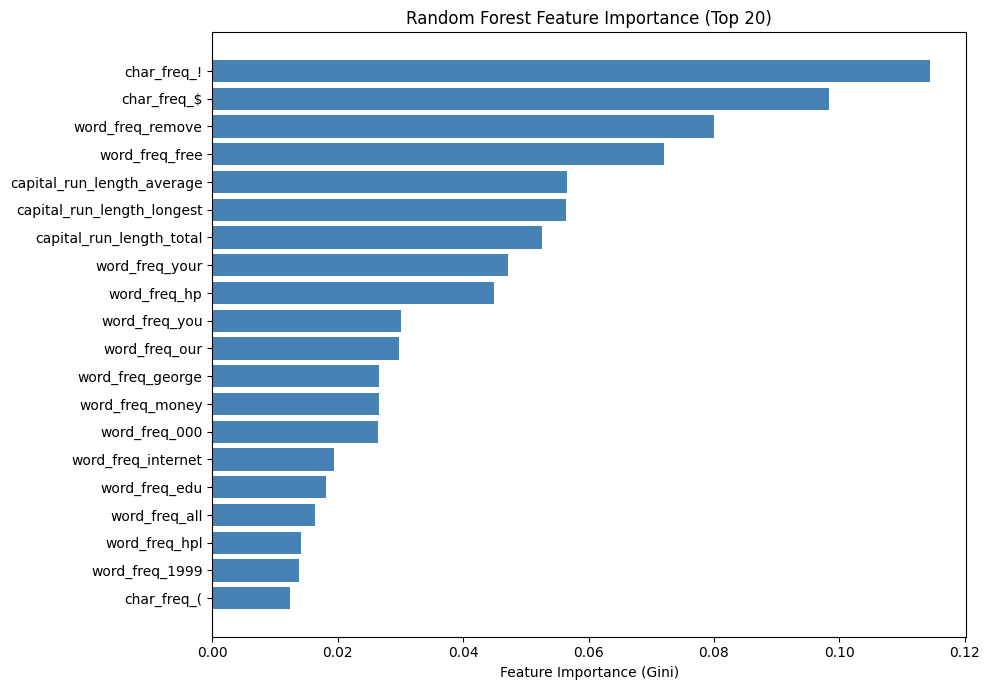

In [10]:
# Problem 2.3: Feature importance from RF with 100 trees
feature_importances = random_forest_models[100].feature_importances_
sorted_importance_indices = np.argsort(feature_importances)[::-1]

# Top 15
print('Top 15 features by importance:')
for rank in range(15):
    feature_index = sorted_importance_indices[rank]
    print(f'  {rank+1:2d}. {feature_names[feature_index]:<35s} {feature_importances[feature_index]:.4f}')

# Plot top 20 features
top_n_features = 20
top_feature_indices = sorted_importance_indices[:top_n_features]

plt.figure(figsize=(10, 7))
plt.barh(range(top_n_features), feature_importances[top_feature_indices][::-1], color='steelblue')
plt.yticks(range(top_n_features), [feature_names[i] for i in top_feature_indices][::-1])
plt.xlabel('Feature Importance (Gini)')
plt.title('Random Forest Feature Importance (Top 20)')
plt.tight_layout()
plt.savefig('rf_feature_importance.png', dpi=150)
plt.show()

---
## Problem 3: AdaBoost Ensemble

### Part 1: AdaBoost with T = 10, 50, 100, 500

In [11]:
# Problem 3.1: AdaBoost with decision tree base classifiers
adaboost_models = {}

for n_estimators in n_estimators_list:
    adaboost = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1),
        n_estimators=n_estimators, random_state=42
    )
    adaboost.fit(X_train, y_train)
    adaboost_models[n_estimators] = adaboost
    
    # Training metrics
    y_train_pred_ada = adaboost.predict(X_train)
    y_train_proba_ada = adaboost.predict_proba(X_train)[:, 1]
    train_accuracy_ada = accuracy_score(y_train, y_train_pred_ada)
    train_f1_ada = f1_score(y_train, y_train_pred_ada)
    train_auc_ada = roc_auc_score(y_train, y_train_proba_ada)
    
    # Testing metrics
    y_test_pred_ada = adaboost.predict(X_test)
    y_test_proba_ada = adaboost.predict_proba(X_test)[:, 1]
    test_accuracy_ada = accuracy_score(y_test, y_test_pred_ada)
    test_f1_ada = f1_score(y_test, y_test_pred_ada)
    test_auc_ada = roc_auc_score(y_test, y_test_proba_ada)
    
    print(f'--- AdaBoost (T={n_estimators}) ---')
    print(f'  Train: Accuracy={train_accuracy_ada:.4f}, F1={train_f1_ada:.4f}, AUC={train_auc_ada:.4f}')
    print(f'  Test:  Accuracy={test_accuracy_ada:.4f}, F1={test_f1_ada:.4f}, AUC={test_auc_ada:.4f}')
    print()

--- AdaBoost (T=10) ---
  Train: Accuracy=0.9142, F1=0.8880, AUC=0.9643
  Test:  Accuracy=0.9149, F1=0.8935, AUC=0.9663

--- AdaBoost (T=50) ---
  Train: Accuracy=0.9310, F1=0.9107, AUC=0.9789
  Test:  Accuracy=0.9357, F1=0.9204, AUC=0.9800

--- AdaBoost (T=100) ---
  Train: Accuracy=0.9357, F1=0.9156, AUC=0.9821
  Test:  Accuracy=0.9357, F1=0.9196, AUC=0.9819

--- AdaBoost (T=500) ---
  Train: Accuracy=0.9487, F1=0.9329, AUC=0.9898
  Test:  Accuracy=0.9479, F1=0.9356, AUC=0.9854



### Part 2: AdaBoost vs. Random Forest Comparison

In [12]:
# Problem 3.2: Side-by-side comparison of RF vs AdaBoost across all T values
for n_estimators in n_estimators_list:
    random_forest = random_forest_models[n_estimators]
    adaboost = adaboost_models[n_estimators]
    
    # Random Forest metrics
    rf_train_accuracy = accuracy_score(y_train, random_forest.predict(X_train))
    rf_test_accuracy = accuracy_score(y_test, random_forest.predict(X_test))
    rf_train_f1 = f1_score(y_train, random_forest.predict(X_train))
    rf_test_f1 = f1_score(y_test, random_forest.predict(X_test))
    rf_train_auc = roc_auc_score(y_train, random_forest.predict_proba(X_train)[:, 1])
    rf_test_auc = roc_auc_score(y_test, random_forest.predict_proba(X_test)[:, 1])
    
    # AdaBoost metrics
    ada_train_accuracy = accuracy_score(y_train, adaboost.predict(X_train))
    ada_test_accuracy = accuracy_score(y_test, adaboost.predict(X_test))
    ada_train_f1 = f1_score(y_train, adaboost.predict(X_train))
    ada_test_f1 = f1_score(y_test, adaboost.predict(X_test))
    ada_train_auc = roc_auc_score(y_train, adaboost.predict_proba(X_train)[:, 1])
    ada_test_auc = roc_auc_score(y_test, adaboost.predict_proba(X_test)[:, 1])
    
    print(f'=== T = {n_estimators} ===')
    print(f'  {"Metric":<10} {"RF Train":>10} {"RF Test":>10} {"Ada Train":>10} {"Ada Test":>10}')
    print(f'  {"-"*52}')
    print(f'  {"Accuracy":<10} {rf_train_accuracy:>10.4f} {rf_test_accuracy:>10.4f} {ada_train_accuracy:>10.4f} {ada_test_accuracy:>10.4f}')
    print(f'  {"F1":<10} {rf_train_f1:>10.4f} {rf_test_f1:>10.4f} {ada_train_f1:>10.4f} {ada_test_f1:>10.4f}')
    print(f'  {"AUC":<10} {rf_train_auc:>10.4f} {rf_test_auc:>10.4f} {ada_train_auc:>10.4f} {ada_test_auc:>10.4f}')
    print()

=== T = 10 ===
  Metric       RF Train    RF Test  Ada Train   Ada Test
  ----------------------------------------------------
  Accuracy       0.9957     0.9461     0.9142     0.9149
  F1             0.9944     0.9329     0.8880     0.8935
  AUC            0.9999     0.9818     0.9643     0.9663

=== T = 50 ===
  Metric       RF Train    RF Test  Ada Train   Ada Test
  ----------------------------------------------------
  Accuracy       0.9994     0.9583     0.9310     0.9357
  F1             0.9993     0.9482     0.9107     0.9204
  AUC            1.0000     0.9884     0.9789     0.9800

=== T = 100 ===
  Metric       RF Train    RF Test  Ada Train   Ada Test
  ----------------------------------------------------
  Accuracy       0.9994     0.9583     0.9357     0.9357
  F1             0.9993     0.9482     0.9156     0.9196
  AUC            1.0000     0.9879     0.9821     0.9819

=== T = 500 ===
  Metric       RF Train    RF Test  Ada Train   Ada Test
  ---------------------------

### Part 3: ROC Curves (DT, RF-100, AdaBoost-100)

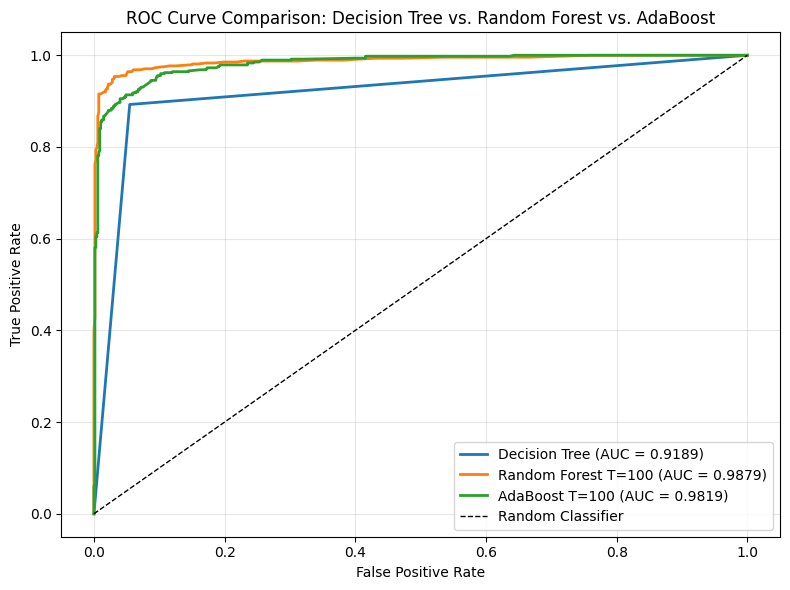

In [13]:
# Problem 3.3: ROC curves for Decision Tree, RF(100), AdaBoost(100)
plt.figure(figsize=(8, 6))

# Decision Tree (entropy, no pruning) -- uses probabilities from Problem 1.1
fpr_decision_tree, tpr_decision_tree, _ = roc_curve(y_test, y_test_proba_entropy)
auc_decision_tree = auc(fpr_decision_tree, tpr_decision_tree)
plt.plot(fpr_decision_tree, tpr_decision_tree, linewidth=2,
         label=f'Decision Tree (AUC = {auc_decision_tree:.4f})')

# Random Forest (T=100)
y_test_proba_rf100 = random_forest_models[100].predict_proba(X_test)[:, 1]
fpr_random_forest, tpr_random_forest, _ = roc_curve(y_test, y_test_proba_rf100)
auc_random_forest = auc(fpr_random_forest, tpr_random_forest)
plt.plot(fpr_random_forest, tpr_random_forest, linewidth=2,
         label=f'Random Forest T=100 (AUC = {auc_random_forest:.4f})')

# AdaBoost (T=100)
y_test_proba_ada100 = adaboost_models[100].predict_proba(X_test)[:, 1]
fpr_adaboost, tpr_adaboost, _ = roc_curve(y_test, y_test_proba_ada100)
auc_adaboost = auc(fpr_adaboost, tpr_adaboost)
plt.plot(fpr_adaboost, tpr_adaboost, linewidth=2,
         label=f'AdaBoost T=100 (AUC = {auc_adaboost:.4f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison: Decision Tree vs. Random Forest vs. AdaBoost')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_comparison.png', dpi=150)
plt.show()

---
## Problem 4: Naive Bayes Classifier (Mushroom Dataset)

### Data Loading: Mushroom Dataset

In [14]:
# Mushroom dataset: 22 categorical attributes, class label is first column
# Attributes from UCI documentation
mushroom_cols = [
    'class', 'cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor',
    'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color',
    'stalk-shape', 'stalk-root', 'stalk-surface-above-ring',
    'stalk-surface-below-ring', 'stalk-color-above-ring',
    'stalk-color-below-ring', 'veil-type', 'veil-color',
    'ring-number', 'ring-type', 'spore-print-color',
    'population', 'habitat'
]

df_mush = pd.read_csv('agaricus-lepiota.data', header=None, names=mushroom_cols)

# Handle missing values encoded as '?'
print(f'Dataset shape: {df_mush.shape}')
print(f'Missing values per column:')
print((df_mush == '?').sum()[lambda x: x > 0])

# Class distribution
print(f'\nClass distribution:')
print(df_mush['class'].value_counts())

# Encode class: e=edible(0), p=poisonous(1)
y_mush = (df_mush['class'] == 'p').astype(int).values
X_mush_df = df_mush.drop('class', axis=1)

# 75/25 split
X_mush_train, X_mush_test, y_mush_train, y_mush_test = train_test_split(
    X_mush_df, y_mush, test_size=0.25, random_state=42
)

print(f'\nTraining set: {X_mush_train.shape[0]} samples')
print(f'Testing set:  {X_mush_test.shape[0]} samples')

Dataset shape: (8124, 23)
Missing values per column:
stalk-root    2480
dtype: int64

Class distribution:
class
e    4208
p    3916
Name: count, dtype: int64

Training set: 6093 samples
Testing set:  2031 samples


### Part 1: Compute Prior and Conditional Probabilities (with Laplace Smoothing)

In [15]:
# Problem 4.1: Naive Bayes from scratch with Laplace smoothing

class NaiveBayesCategorical:
    """Naive Bayes for categorical features with Laplace smoothing."""
    
    def fit(self, X_dataframe, y_labels):
        """Compute prior P(Y) and conditional P(Xi=x|Y) from training data."""
        self.classes = np.unique(y_labels)
        self.feature_columns = X_dataframe.columns.tolist()
        n_samples = len(y_labels)
        
        # Prior probabilities P(Y=c)
        self.prior_probabilities = {}
        for class_label in self.classes:
            self.prior_probabilities[class_label] = np.sum(y_labels == class_label) / n_samples
        
        # Conditional probabilities P(Xi=x | Y=c) with Laplace smoothing
        # For each feature, for each class, compute smoothed probability of each category
        self.conditional_probabilities = {}
        
        for feature in self.feature_columns:
            self.conditional_probabilities[feature] = {}
            # All unique values this feature takes across the entire training set
            all_categories = X_dataframe[feature].unique()
            n_categories = len(all_categories)
            
            for class_label in self.classes:
                class_mask = (y_labels == class_label)
                class_feature_values = X_dataframe.loc[class_mask, feature]
                n_class_samples = class_mask.sum()
                
                self.conditional_probabilities[feature][class_label] = {}
                for category in all_categories:
                    # Laplace smoothing: (count + 1) / (n_class + n_categories)
                    category_count = (class_feature_values == category).sum()
                    smoothed_probability = (category_count + 1) / (n_class_samples + n_categories)
                    self.conditional_probabilities[feature][class_label][category] = smoothed_probability
        
        return self
    
    def predict_proba(self, X_dataframe):
        """Compute P(Y=c|X) for each sample using Bayes' rule + naive assumption."""
        log_posteriors = np.zeros((len(X_dataframe), len(self.classes)))
        
        for sample_index, (_, row) in enumerate(X_dataframe.iterrows()):
            for class_index, class_label in enumerate(self.classes):
                # Start with log prior
                log_posterior = np.log(self.prior_probabilities[class_label])
                
                for feature in self.feature_columns:
                    feature_value = row[feature]
                    if feature_value in self.conditional_probabilities[feature][class_label]:
                        log_posterior += np.log(self.conditional_probabilities[feature][class_label][feature_value])
                    else:
                        # Unseen category: use Laplace smoothing fallback
                        n_known_categories = len(self.conditional_probabilities[feature][class_label])
                        log_posterior += np.log(1 / (n_known_categories + n_known_categories + 1))
                
                log_posteriors[sample_index, class_index] = log_posterior
        
        # Convert log probabilities to normalized probabilities
        # Subtract max for numerical stability before exp
        log_posteriors = log_posteriors - log_posteriors.max(axis=1, keepdims=True)
        posteriors = np.exp(log_posteriors)
        posteriors = posteriors / posteriors.sum(axis=1, keepdims=True)
        
        return posteriors
    
    def predict(self, X_dataframe):
        """Predict class labels."""
        posteriors = self.predict_proba(X_dataframe)
        return self.classes[np.argmax(posteriors, axis=1)]


# Train
naive_bayes_custom = NaiveBayesCategorical()
naive_bayes_custom.fit(X_mush_train, y_mush_train)

# Print priors
print('Prior probabilities:')
print(f'  P(Edible)    = {naive_bayes_custom.prior_probabilities[0]:.4f}')
print(f'  P(Poisonous) = {naive_bayes_custom.prior_probabilities[1]:.4f}')

# Print sample conditional probabilities for first 3 features
print('\nSample conditional probabilities (first 3 features):')
for feature in naive_bayes_custom.feature_columns[:3]:
    print(f'\n  Feature: {feature}')
    for class_label in naive_bayes_custom.classes:
        class_name = 'Edible' if class_label == 0 else 'Poisonous'
        print(f'    P({feature}=x | {class_name}):')
        for category, probability in sorted(naive_bayes_custom.conditional_probabilities[feature][class_label].items()):
            print(f'      {category}: {probability:.4f}')

Prior probabilities:
  P(Edible)    = 0.5199
  P(Poisonous) = 0.4801

Sample conditional probabilities (first 3 features):

  Feature: cap-shape
    P(cap-shape=x | Edible):
      b: 0.0888
      c: 0.0003
      f: 0.3774
      k: 0.0577
      s: 0.0079
      x: 0.4679
    P(cap-shape=x | Poisonous):
      b: 0.0136
      c: 0.0014
      f: 0.3889
      k: 0.1586
      s: 0.0003
      x: 0.4371

  Feature: cap-surface
    P(cap-surface=x | Edible):
      f: 0.3698
      g: 0.0003
      s: 0.2708
      y: 0.3591
    P(cap-surface=x | Poisonous):
      f: 0.1939
      g: 0.0010
      s: 0.3585
      y: 0.4466

  Feature: cap-color
    P(cap-color=x | Edible):
      b: 0.0132
      c: 0.0088
      e: 0.1466
      g: 0.2458
      n: 0.2967
      p: 0.0148
      r: 0.0038
      u: 0.0047
      w: 0.1734
      y: 0.0922
    P(cap-color=x | Poisonous):
      b: 0.0324
      c: 0.0041
      e: 0.2194
      g: 0.2020
      n: 0.2624
      p: 0.0225
      r: 0.0003
      u: 0.0003
      w: 0.083

### Part 2: Predict on Test Set

In [16]:
# Problem 4.2: Predict on test set
y_mush_test_pred_custom = naive_bayes_custom.predict(X_mush_test)
y_mush_test_proba_custom = naive_bayes_custom.predict_proba(X_mush_test)

# Show first 10 predictions with probabilities
print('First 10 test predictions:')
print(f'{"Sample":<8} {"True":<12} {"Predicted":<12} {"P(Edible)":>12} {"P(Poisonous)":>14}')
print('-' * 60)
for sample_index in range(10):
    true_class = y_mush_test[sample_index]
    true_label = 'Edible' if true_class == 0 else 'Poisonous'
    predicted_class = y_mush_test_pred_custom[sample_index]
    predicted_label = 'Edible' if predicted_class == 0 else 'Poisonous'
    probability_edible = y_mush_test_proba_custom[sample_index, 0]
    probability_poisonous = y_mush_test_proba_custom[sample_index, 1]
    print(f'{sample_index+1:<8} {true_label:<12} {predicted_label:<12} {probability_edible:>12.6f} {probability_poisonous:>14.6f}')

First 10 test predictions:
Sample   True         Predicted       P(Edible)   P(Poisonous)
------------------------------------------------------------
1        Edible       Edible           0.999993       0.000007
2        Poisonous    Poisonous        0.000000       1.000000
3        Poisonous    Poisonous        0.000000       1.000000
4        Edible       Edible           1.000000       0.000000
5        Poisonous    Poisonous        0.000000       1.000000
6        Poisonous    Poisonous        0.000000       1.000000
7        Poisonous    Poisonous        0.001675       0.998325
8        Poisonous    Poisonous        0.000000       1.000000
9        Edible       Edible           1.000000       0.000000
10       Edible       Edible           0.999999       0.000001


### Part 3: Custom NB Metrics

In [17]:
# Problem 4.3: Metrics for custom NB
custom_accuracy = accuracy_score(y_mush_test, y_mush_test_pred_custom)
custom_precision = precision_score(y_mush_test, y_mush_test_pred_custom)
custom_recall = recall_score(y_mush_test, y_mush_test_pred_custom)
custom_f1 = f1_score(y_mush_test, y_mush_test_pred_custom)

print('Custom Naive Bayes Metrics:')
print(f'  Accuracy:  {custom_accuracy:.4f}')
print(f'  Precision: {custom_precision:.4f}')
print(f'  Recall:    {custom_recall:.4f}')
print(f'  F1 Score:  {custom_f1:.4f}')

# Confusion matrix
custom_confusion_matrix = confusion_matrix(y_mush_test, y_mush_test_pred_custom)
print(f'\nConfusion Matrix:')
print(f'                    Predicted Edible  Predicted Poisonous')
print(f'  Actual Edible     {custom_confusion_matrix[0,0]:>15}  {custom_confusion_matrix[0,1]:>19}')
print(f'  Actual Poisonous  {custom_confusion_matrix[1,0]:>15}  {custom_confusion_matrix[1,1]:>19}')

Custom Naive Bayes Metrics:
  Accuracy:  0.9488
  Precision: 0.9901
  Recall:    0.9041
  F1 Score:  0.9451

Confusion Matrix:
                    Predicted Edible  Predicted Poisonous
  Actual Edible                1031                    9
  Actual Poisonous               95                  896


### Part 4: Comparison with Package (sklearn CategoricalNB)

In [18]:
# Problem 4.4: Compare with sklearn CategoricalNB
from sklearn.naive_bayes import CategoricalNB
from sklearn.preprocessing import OrdinalEncoder

# Encode categorical features as integers for sklearn
ordinal_encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_mush_train_encoded = ordinal_encoder.fit_transform(X_mush_train)
X_mush_test_encoded = ordinal_encoder.transform(X_mush_test)

# Train sklearn CategoricalNB with Laplace smoothing (alpha=1)
naive_bayes_sklearn = CategoricalNB(alpha=1.0)
naive_bayes_sklearn.fit(X_mush_train_encoded, y_mush_train)

y_mush_test_pred_sklearn = naive_bayes_sklearn.predict(X_mush_test_encoded)

sklearn_accuracy = accuracy_score(y_mush_test, y_mush_test_pred_sklearn)
sklearn_precision = precision_score(y_mush_test, y_mush_test_pred_sklearn)
sklearn_recall = recall_score(y_mush_test, y_mush_test_pred_sklearn)
sklearn_f1 = f1_score(y_mush_test, y_mush_test_pred_sklearn)

print('Comparison: Custom NB vs. sklearn CategoricalNB')
print(f'{"Metric":<12} {"Custom":>10} {"sklearn":>10} {"Diff":>10}')
print('-' * 44)
print(f'{"Accuracy":<12} {custom_accuracy:>10.4f} {sklearn_accuracy:>10.4f} {abs(custom_accuracy - sklearn_accuracy):>10.4f}')
print(f'{"Precision":<12} {custom_precision:>10.4f} {sklearn_precision:>10.4f} {abs(custom_precision - sklearn_precision):>10.4f}')
print(f'{"Recall":<12} {custom_recall:>10.4f} {sklearn_recall:>10.4f} {abs(custom_recall - sklearn_recall):>10.4f}')
print(f'{"F1 Score":<12} {custom_f1:>10.4f} {sklearn_f1:>10.4f} {abs(custom_f1 - sklearn_f1):>10.4f}')

Comparison: Custom NB vs. sklearn CategoricalNB
Metric           Custom    sklearn       Diff
--------------------------------------------
Accuracy         0.9488     0.9488     0.0000
Precision        0.9901     0.9901     0.0000
Recall           0.9041     0.9041     0.0000
F1 Score         0.9451     0.9451     0.0000
